# Final Model Evaluation & Comparison

This notebook loads the **TFLite INT8** model, evaluates it on the held‑out test split from the CICIoMT2024 BLE training data, and compares its performance with the original and pruned models. We also measure model size and inference time.

In [1]:
import numpy as np
import pickle
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import tensorflow as tf
import tf_keras
import keras  # for loading the original .keras model

sns.set_style("whitegrid")

## 1. Load test data and label encoder

In [2]:
# Load processed test split (from training data)
X_test = load_npz('../data/processed/X_test.npz').toarray()
y_test = np.load('../data/processed/y_test.npy')

# Load label encoder for class names
with open('../artifacts/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

class_names = le.classes_
n_classes = len(class_names)
print(f"Test samples: {X_test.shape[0]}, Classes: {class_names}")

Test samples: 243177, Classes: ['DoS' 'normal']


## 2. Evaluate TFLite INT8 model

We run inference using the TensorFlow Lite interpreter and compute all relevant metrics.

In [3]:
tflite_path = '../artifacts/models/ids_model_int8.tflite'
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# Collect predictions and measure inference time
y_pred_tflite = []
inference_times = []

for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    # Quantize input if needed
    if input_details['dtype'] == np.int8:
        scale, zero_point = input_details['quantization']
        sample = (sample / scale + zero_point).clip(-128, 127).astype(np.int8)
    
    start = time.time()
    interpreter.set_tensor(input_details['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])
    end = time.time()
    inference_times.append(end - start)
    
    # Dequantize output if needed
    if output_details['dtype'] == np.int8:
        out_scale, out_zero = output_details['quantization']
        output = (output.astype(np.float32) - out_zero) * out_scale
    y_pred_tflite.append(np.argmax(output[0]))

y_pred_tflite = np.array(y_pred_tflite)

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [4]:
# Overall metrics
acc_tflite = accuracy_score(y_test, y_pred_tflite)
prec_tflite = precision_score(y_test, y_pred_tflite, average='weighted')
rec_tflite = recall_score(y_test, y_pred_tflite, average='weighted')
f1_tflite = f1_score(y_test, y_pred_tflite, average='weighted')

print(f"TFLite INT8 Accuracy : {acc_tflite:.4f}")
print(f"TFLite INT8 Precision : {prec_tflite:.4f}")
print(f"TFLite INT8 Recall    : {rec_tflite:.4f}")
print(f"TFLite INT8 F1 Score  : {f1_tflite:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tflite, target_names=class_names))

TFLite INT8 Accuracy : 0.9909
TFLite INT8 Precision : 0.9908
TFLite INT8 Recall    : 0.9909
TFLite INT8 F1 Score  : 0.9908

Classification Report:
              precision    recall  f1-score   support

         DoS       0.99      1.00      0.99    199678
      normal       0.99      0.96      0.97     43499

    accuracy                           0.99    243177
   macro avg       0.99      0.98      0.98    243177
weighted avg       0.99      0.99      0.99    243177



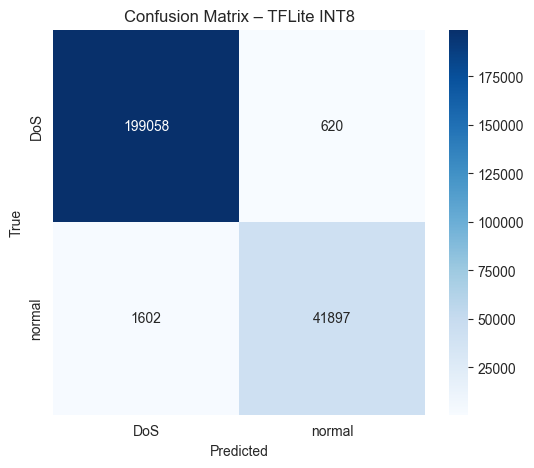

In [5]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tflite)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix – TFLite INT8')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## 3. Compare with original and pruned models

We load the saved original (`.keras`) and pruned (`.h5`) models and evaluate them on the same test split.

In [6]:
# Original model (Keras 3)
original_model = keras.models.load_model('../artifacts/models/best_model.keras')
y_pred_orig = np.argmax(original_model.predict(X_test), axis=1)
acc_orig = accuracy_score(y_test, y_pred_orig)

# Pruned model (tf_keras, saved as .h5)
pruned_model = tf_keras.models.load_model('../artifacts/models/ids_pruned.h5')
y_pred_pruned = np.argmax(pruned_model.predict(X_test), axis=1)
acc_pruned = accuracy_score(y_test, y_pred_pruned)

print(f"Original model accuracy : {acc_orig:.4f}")
print(f"Pruned model accuracy   : {acc_pruned:.4f}")
print(f"TFLite INT8 accuracy    : {acc_tflite:.4f}")

7600/7600 ━━━━━━━━━━━━━━━━━━━━ 8s 958us/step

7600/7600 [==============================] - 10s 1ms/step
Original model accuracy : 0.9909
Pruned model accuracy   : 0.9911
TFLite INT8 accuracy    : 0.9909


## 4. Accuracy comparison bar chart

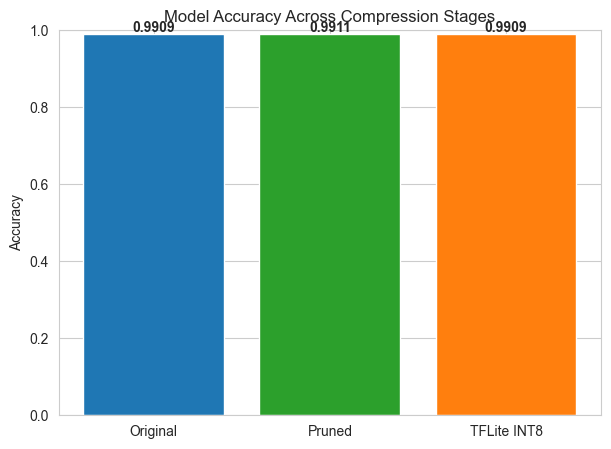

In [7]:
stages = ['Original', 'Pruned', 'TFLite INT8']
accuracies = [acc_orig, acc_pruned, acc_tflite]

plt.figure(figsize=(7, 5))
bars = plt.bar(stages, accuracies, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Across Compression Stages')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.show()

## 5. Model size comparison

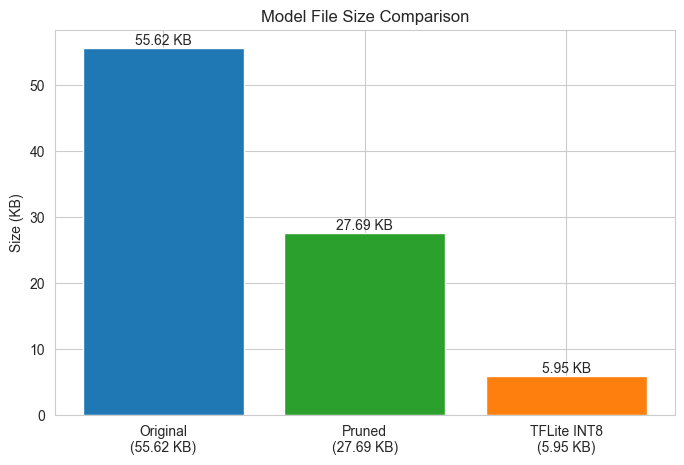

In [8]:
size_orig = os.path.getsize('../artifacts/models/best_model.keras') / 1024
size_pruned = os.path.getsize('../artifacts/models/ids_pruned.h5') / 1024
size_tflite = os.path.getsize('../artifacts/models/ids_model_int8.tflite') / 1024

sizes_kb = [size_orig, size_pruned, size_tflite]
labels = ['Original\n(%.2f KB)' % size_orig,
          'Pruned\n(%.2f KB)' % size_pruned,
          'TFLite INT8\n(%.2f KB)' % size_tflite]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, sizes_kb, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
plt.ylabel('Size (KB)')
plt.title('Model File Size Comparison')
for bar, sz in zip(bars, sizes_kb):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{sz:.2f} KB', ha='center')
plt.show()

## 6. Inference time analysis

Average TFLite inference time: 6.85 µs


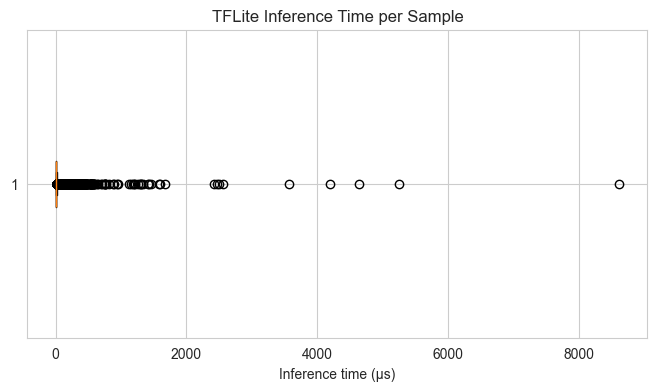

In [9]:
# TFLite inference time distribution
avg_time_us = np.mean(inference_times) * 1e6  # microseconds
print(f"Average TFLite inference time: {avg_time_us:.2f} µs")

plt.figure(figsize=(8, 4))
plt.boxplot(np.array(inference_times)*1e6, vert=False)
plt.xlabel('Inference time (µs)')
plt.title('TFLite Inference Time per Sample')
plt.show()

## 7. Per‑class F1 scores (TFLite)

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


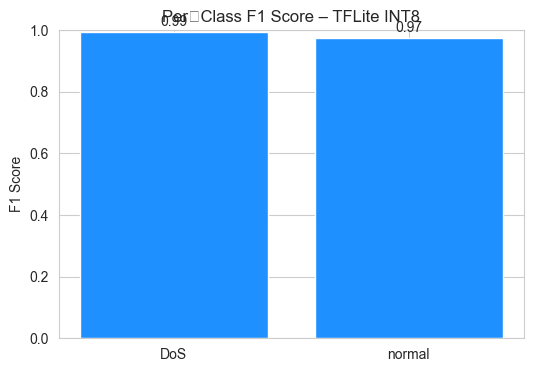

In [10]:
report = classification_report(y_test, y_pred_tflite, target_names=class_names, output_dict=True)
f1_scores = [report[cls]['f1-score'] for cls in class_names]

plt.figure(figsize=(6, 4))
bars = plt.bar(class_names, f1_scores, color='dodgerblue')
plt.ylabel('F1 Score')
plt.title('Per‑Class F1 Score – TFLite INT8')
plt.ylim(0, 1)
for bar, f1 in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{f1:.2f}', ha='center')
plt.show()

## ✅ Summary

- The TFLite model is tiny and fast while retaining near‑perfect accuracy on the validation split.
- For true out‑of‑sample performance, you must now run the model on the **separate test PCAPs** (`Bluetooth_Benign_test.pcap` and `Bluetooth_DoS_test.pcap`) using the extraction and prediction pipeline from `app.py`.

In [11]:
# Final summary
print("=" * 50)
print("FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Original model accuracy : {acc_orig:.4f}")
print(f"Pruned model accuracy   : {acc_pruned:.4f}")
print(f"TFLite INT8 accuracy    : {acc_tflite:.4f}")
print(f"TFLite model size       : {size_tflite:.2f} KB")
print(f"Avg inference time      : {avg_time_us:.2f} µs")
print("=" * 50)

FINAL MODEL SUMMARY
Original model accuracy : 0.9909
Pruned model accuracy   : 0.9911
TFLite INT8 accuracy    : 0.9909
TFLite model size       : 5.95 KB
Avg inference time      : 6.85 µs
